# Experiment Setup

Log for defining experiment parameters.

## Table of Contents

1. [Properties of the case [2026-01-28]](#properties-of-the-case)
2. [Sea-states [2026-01-29]](#sea-states)

<a id="properties-of-the-case"></a>

## Properties of the case [2026-01-28]

In [49]:
using Pkg
Pkg.activate("/home/shagun/Acads/HydroElasticFEM.jl")

using HydroElasticFEM
PKG_ROOT = HydroElasticFEM.PKG_ROOT

using JLD2
using Printf
using DataFrames
using Plots
using Printf

  Activating project at `~/Acads/HydroElasticFEM.jl`


### Option 1: LDPE Lm=50

Still-water depth = H0 = 25m

```Julia
E = 100e6 #Pa
ρ = 910 #kg/m3

Lm = 50.0 #m
h_memb = 0.05 #m
ϵx = 0.002 #Pre Strain 

σx = E*ϵx #Pre stress
T = σx*h_memb #Pre tension

m = ρ*h_memb #Mass per unit area
```


```Console
Typical Yield Strength (TYS) = 10MPa
Pre-Stress σx = 0.20 MPa = 2.0% TYS

[MSG] Membrane Properties:
[VAL] Density of water, ρw = 1025.00 kg/m3
[VAL] Lm = 50.0000 m
[VAL] m, mᵨ = 45.5000 kg/m2, 0.0444 m
[VAL] T, Tᵨ = 10000.0000 N/m, 9.7561 m3/s2
[VAL] τ = 0.0000 
[VAL] memBndType = HydroElasticFEM.Membrane.Free() 
[VAL] MTotal = 2275.0000 kg/m 
[VAL] 1st Dry Analytical Natural Freq, ωn1 = 0.9315 rad/s 

[MSG] Resonator Properties:
[VAL] M = 113.7500 kg
[VAL] K = 28.4375 N/m
[VAL] C = 0.0000 Ns/m
[VAL] XZ = (75.0000, 0.0000) m
[VAL] ωn1 = 0.5000 rad/s

```

Mesh = (0,50,100,150)
nx,nz = (375, 15, 1.15)

**Dry Natural Freqs**

```Console
7×3 DataFrame
 Row │ ωn                V                                  meff             
     │ Complex…          Array…                             Complex…         
─────┼───────────────────────────────────────────────────────────────────────
   1 │ 2.62313e-6+0.0im  ComplexF64[0.0629941+0.0im, 0.06…    0.460196+0.0im
   2 │   0.509199+0.0im  ComplexF64[-0.04433+0.0im, -0.04…      69.492+0.0im
   3 │   0.931481+0.0im  ComplexF64[-0.0890871+0.0im, -0.…  0.00880759+0.0im
   4 │    1.87016+0.0im  ComplexF64[-0.0889154+0.0im, -0.…    0.014137+0.0im
   5 │    2.79444+0.0im  ComplexF64[0.0890871+0.0im, 0.08…  0.00880759+0.0im
   6 │    3.72934+0.0im  ComplexF64[0.0890465+0.0im, 0.08…  0.00910986+0.0im
   7 │    4.65741+0.0im  ComplexF64[-0.0890871-0.0im, -0.…  0.00880758+0.0im
```

**Wet Natural Freqs**

```Console
7×4 DataFrame
 Row │ ωn                     V                                  meff                  iter  
     │ Complex…               Any                                Any                   Int64 
─────┼───────────────────────────────────────────────────────────────────────────────────────
   1 │      0.0+0.0im         ComplexF64[0.0+0.0im, 0.0+0.0im,…  0.0+0.0im                 0
   2 │ 0.499651-1.55955e-5im  ComplexF64[-4.51676e-5+4.09873e-…  113.749+4.87304e-6im      2
   3 │ 0.971825-0.193344im    ComplexF64[-0.0746939-0.0264458i…  1.71952+0.148832im       12
   4 │  1.24908-0.168326im    ComplexF64[0.0876051+0.00847866i…  0.868607-0.389205im      14
   5 │  1.48423-0.157743im    ComplexF64[-0.0940719-0.00137344…  0.53592-0.311784im       13
   6 │   1.6994-0.149686im    ComplexF64[0.0983227+0.000479656…  0.419326-0.197135im      12
   7 │   1.9054-0.142164im    ComplexF64[-0.10142-1.82063e-13i…  0.348002-0.122468im      11
```

#### Mode Shape

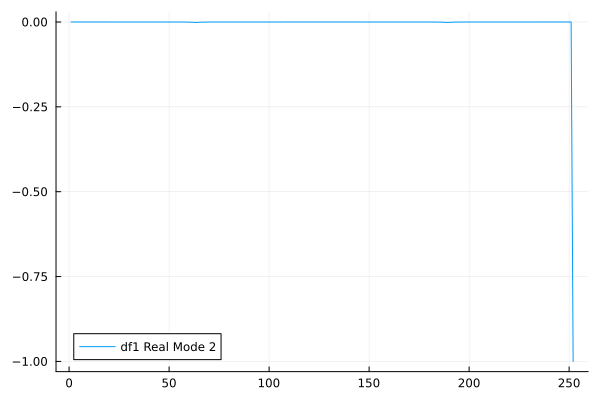

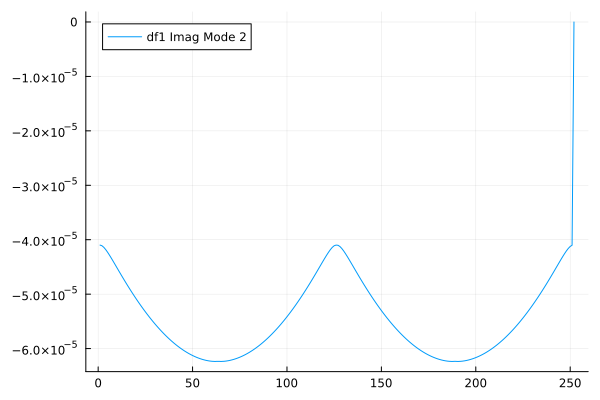

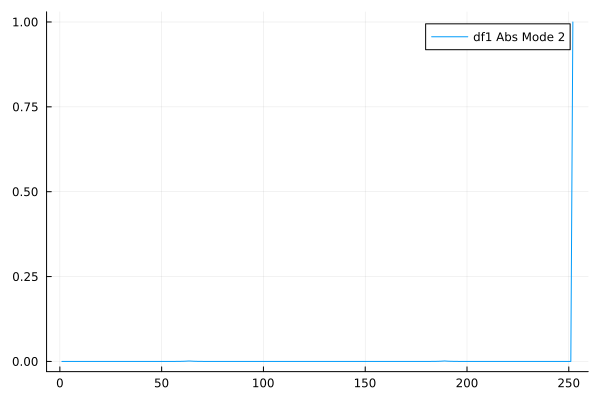

┌ Warning: type Main.Memb_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


In [50]:
fileName = "data/paper2026_01/01_ExperimentSetup/"
fileName *= "modes_LRHS_Lm50_mesh2/memb_mrho=0.04_Trho=9.76/"
fileName *= "lrhs_complexMass_free_resnM=113.75_resnK=28.44_modesdata.jld2"
df1 = load(PKG_ROOT*fileName)

mode = 2
df1_V = df1["dfWet"][:,"V"][mode]
df1_V = df1_V ./ sign(real(df1_V[1]))
plot()
plot!(real(df1_V), label="df1 Real Mode $mode")
display(plot!())

plot()
plot!(imag(df1_V), label="df1 Imag Mode $mode")
display(plot!())

plot()
plot!(abs.(df1_V), label="df1 Abs Mode $mode", legend=:topright)
display(plot!())


---

### Option 2: LDPE Lm=40

Still-water depth = H0 = 25m

```Julia
E = 100e6 #Pa
ρ = 910 #kg/m3

Lm = 40.0 #m
h_memb = 0.05 #m
ϵx = 0.002 #Pre Strain 

σx = E*ϵx #Pre stress
T = σx*h_memb #Pre tension

m = ρ*h_memb #Mass per unit area
```


```Console
Typical Yield Strength (TYS) = 10MPa
Pre-StPre-Stress σx = 0.20 MPa = 2% TYS

[MSG] Membrane Properties:
[VAL] Density of water, ρw = 1025.00 kg/m3
[VAL] Lm = 40.0000 m
[VAL] m, mᵨ = 45.5000 kg/m2, 0.0444 m
[VAL] T, Tᵨ = 10000.0000 N/m, 9.7561 m3/s2
[VAL] τ = 0.0000 
[VAL] memBndType = HydroElasticFEM.Membrane.Free() 
[VAL] MTotal = 1820.0000 kg/m 
[VAL] 1st Dry Analytical Natural Freq, ωn1 = 1.1644 rad/s

[MSG] Resonator Properties:
[VAL] M = 91.0000 kg
[VAL] K = 22.7500 N/m
[VAL] C = 0.0000 Ns/m
[VAL] XZ = (100.0000, 0.0000) m
[VAL] ωn1 = 0.5000 rad/s
```

Mesh = (0,40,80,120)
nx,nz = (375, 15, 1.15)

**Dry Natural Freqs**

```Console
dfDry = 7×3 DataFrame
 Row │ ωn                     V                                  meff
     │ Complex…               Array…                             Complex…
─────┼───────────────────────────────────────────────────────────────────────────
   1 │      0.0+4.40368e-7im  ComplexF64[0.110432-0.0im, 0.110…    1.13141+0.0im
   2 │ 0.510352+0.0im         ComplexF64[-0.0493769+0.0im, -0.…    75.5837+0.0im
   3 │  1.16435+0.0im         ComplexF64[0.156174+0.0im, 0.155…  0.0216538+0.0im
   4 │  2.33432+0.0im         ComplexF64[0.155987-0.0im, 0.154…  0.0267734+0.0im
   5 │  3.49306+0.0im         ComplexF64[0.156174+0.0im, 0.151…  0.0216536+0.0im
   6 │  4.66015+0.0im         ComplexF64[0.15613+0.0im, 0.1484…  0.0219545+0.0im
   7 │  5.82185+0.0im         ComplexF64[-0.156175-0.0im, -0.1…  0.0216526+0.0im
```

**Wet Natural Freqs**

```Console
dfWet = 7×4 DataFrame
 Row │ ωn                   V                                  meff                 iter
     │ Complex…             Any                                Any                  Int64
─────┼────────────────────────────────────────────────────────────────────────────────────
   1 │      0.0+0.0im       ComplexF64[0.0+0.0im, 0.0+0.0im,…  0.0+0.0im                0
   2 │ 0.550111-0.30998im   ComplexF64[0.0971705+0.0490871im…  2.15835+11.0745im       23
   3 │  1.08721-0.208408im  ComplexF64[0.132606+0.0435177im,…  3.44389+0.36807im       12
   4 │  1.39926-0.188568im  ComplexF64[0.154737+0.0103188im,…  1.76861-0.714391im      14
   5 │  1.67156-0.177562im  ComplexF64[0.165706+0.0im, 0.164…  1.14501-0.531259im      13
   6 │  1.92772-0.168234im  ComplexF64[0.172913+6.66828e-15i…  0.906916-0.294921im     12
   7 │  2.18064-0.159221im  ComplexF64[-0.178073-8.01442e-15…  0.75666-0.156892im      11

```



#### Model Shape

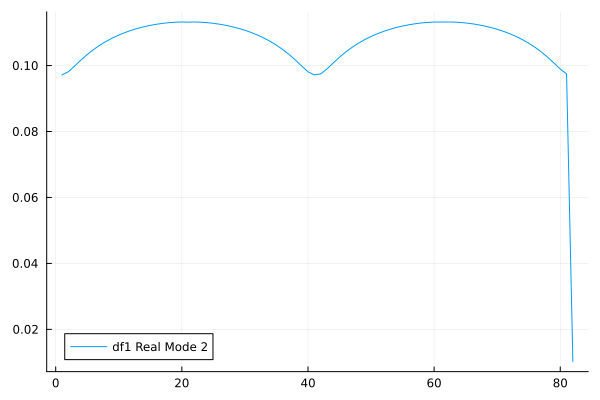

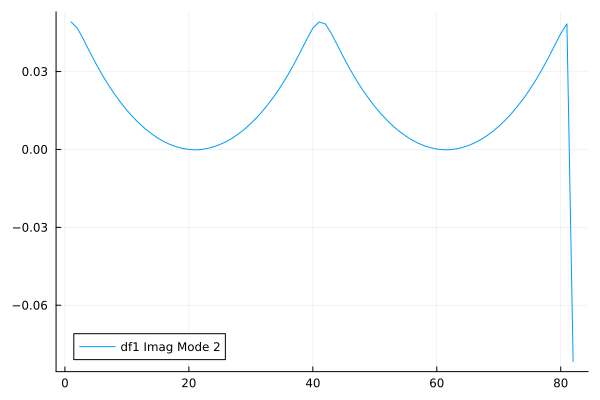

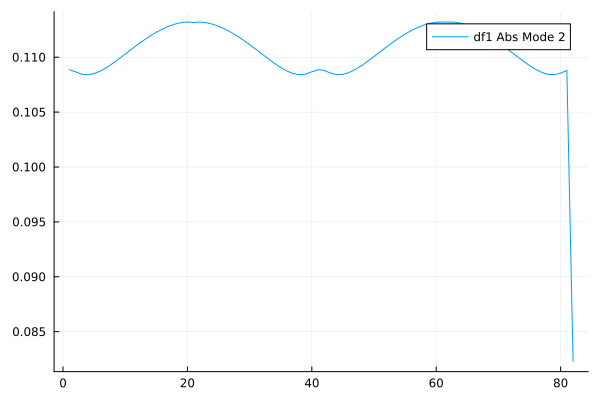

┌ Warning: type Main.Memb_LRHS_params does not exist in workspace; reconstructing
└ @ JLD2 /home/shagun/.julia/packages/JLD2/SgtOb/src/data/reconstructing_datatypes.jl:588


In [51]:
fileName = "data/paper2026_01/01_ExperimentSetup/"
fileName *= "modes_LRHS_Lm40_mesh1/memb_mrho=0.04_Trho=9.76/"
fileName *= "lrhs_complexMass_free_resnM=91.00_resnK=22.75_modesdata.jld2"
df1 = load(PKG_ROOT*fileName)

mode = 2
df1_V = df1["dfWet"][:,"V"][mode]
df1_V = df1_V ./ sign(real(df1_V[1]))
plot()
plot!(real(df1_V), label="df1 Real Mode $mode")
display(plot!())

plot()
plot!(imag(df1_V), label="df1 Imag Mode $mode")
display(plot!())

plot()
plot!(abs.(df1_V), label="df1 Abs Mode $mode", legend=:topright)
display(plot!())


---

---
---

<a id="sea-states"></a>

## Sea-states [2026-01-29]

Define the sea-states to see which range of frequencies should I focus on.

In [52]:
using WaveSpec.Constants
using WaveSpec.Jonswap

In [53]:
function analyse_sea_state(h, Hs, Tp)
  println("Analyzing sea state: Hs = $Hs m, Tp = $Tp s, h = $h m")
  ω, S, A = jonswap(Hs, Tp; plotflag=false,  nω=2401, ωc = 2*pi*2)

  plot(ω, S,
    xlabel = "ω (rad/s)",
    ylabel = "S(ω) (m²s/rad)",
    title = "JONSWAP Spectrum: Hs=$Hs m, Tp=$Tp s",
    xlim = (0, 3),
    legend = false,
  )

  @show peakS = maximum(S)
  @show ω_peakS = ω[argmax(S)]
  @show peakA = maximum(A)

  idx = findall((S .< 0.005*peakS) .& (ω .< ω_peakS))
  ωlow_cutoff = ω[idx[end]]

  idx = findall((S .< 0.005*peakS) .& (ω .> ω_peakS))
  ωhigh_cutoff = ω[idx[1]]

  println()
  println("Low cutoff frequency: ω = $(round(ωlow_cutoff, digits=3)) rad/s")
  println("Wave-length @ low cutoff freq: L = $(round(dispersionRel(h, 2*pi/ωlow_cutoff), digits=2)) m")

  println()
  println("Peak frequency: ω = $(round(ω_peakS, digits=3)) rad/s")
  println("Wave-length @ peak freq: L = $(round(dispersionRel(h, 2*pi/ω_peakS), digits=2)) m")

  println()
  println("High cutoff frequency: ω = $(round(ωhigh_cutoff, digits=3)) rad/s")
  println("Wave-length @ high cutoff freq: L = $(round(dispersionRel(h, 2*pi/ωhigh_cutoff), digits=2)) m")
end

analyse_sea_state (generic function with 1 method)

In [54]:
h = 25 #m still-water dpeth
Hs = 7.0 #m
Tp = 12.4 #s
analyse_sea_state(h, Hs, Tp)

Analyzing sea state: Hs = 7.0 m, Tp = 12.4 s, h = 25 m
Hₛ 	 7.0
Tₚ 	 12.4
ωₚ 	 0.507
γ 	 1.278
Ag 	 0.932
Computed Hₛ 	 7.0
Computed ωₛ 	 0.647
Max(S) 	10.315
Max(A) 	0.329
peakS = maximum(S) = 10.31535902371232
ω_peakS = ω[argmax(S)] = 0.5078908123303499
peakA = maximum(A) = 0.3286672893572658

Low cutoff frequency: ω = 0.309 rad/s
Time Period 	 T 	 20.338983050847457
Water Depth 	 h 	 25
Wave Length 	 L 	 305.5655064976221
Wave Celerity 	 C 	 15.023637402799753
Disp. Regime 	 h/L 	 0.082
Wave-length @ low cutoff freq: L = 305.57 m

Peak frequency: ω = 0.508 rad/s
Time Period 	 T 	 12.371134020618555
Water Depth 	 h 	 25
Wave Length 	 L 	 172.4280587843326
Wave Celerity 	 C 	 13.937934751733552
Disp. Regime 	 h/L 	 0.145
Wave-length @ peak freq: L = 172.43 m

High cutoff frequency: ω = 1.785 rad/s
Time Period 	 T 	 3.5190615835777126
Water Depth 	 h 	 25
Wave Length 	 L 	 19.334938582566885
Wave Celerity 	 C 	 5.494345047212756
Disp. Regime 	 h/L 	 1.293
Wave-length @ high cutoff freq

In [55]:
h = 25 #m still-water dpeth
Hs = 3.0 #m
Tp = 10.0 #s
analyse_sea_state(h, Hs, Tp)

Analyzing sea state: Hs = 3.0 m, Tp = 10.0 s, h = 25 m
ERR: Check criterion Tₚ / √(Hₛ) = 5.773502691896258
Hₛ 	 3.0
Tₚ 	 10.0
ωₚ 	 0.628
γ 	 1.0
Ag 	 1.0
Computed Hₛ 	 3.0
Computed ωₛ 	 0.814
Max(S) 	1.282
Max(A) 	0.116
peakS = maximum(S) = 1.2824721810231359
ω_peakS = ω[argmax(S)] = 0.6283185307179586
peakA = maximum(A) = 0.11588795137740539

Low cutoff frequency: ω = 0.382 rad/s
Time Period 	 T 	 16.438356164383563
Water Depth 	 h 	 25
Wave Length 	 L 	 241.39153060548733
Wave Celerity 	 C 	 14.684651445167145
Disp. Regime 	 h/L 	 0.104
Wave-length @ low cutoff freq: L = 241.39 m

Peak frequency: ω = 0.628 rad/s
Time Period 	 T 	 10.0
Water Depth 	 h 	 25
Wave Length 	 L 	 130.3843232850413
Wave Celerity 	 C 	 13.038432328504129
Disp. Regime 	 h/L 	 0.192
Wave-length @ peak freq: L = 130.38 m

High cutoff frequency: ω = 2.325 rad/s
Time Period 	 T 	 2.7027027027027026
Water Depth 	 h 	 25
Wave Length 	 L 	 11.404747930811505
Wave Celerity 	 C 	 4.2197567344002564
Disp. Regime 	 h/L 	

In [56]:
## Agarwal 2022 Mesh parameters
Lm = 20
spn = 7.5*Lm
updown = 4*Lm
@show total = (spn + 2*updown + Lm )

@show Δx = 0.01*Lm
Nz = 20
@show Nx = Int(total / Δx) 
@show nele = Nx*Nz

# For second order element
@show ndof = (2*Nx+1)*(2*Nz+1)

total = spn + 2updown + Lm = 330.0
Δx = 0.01Lm = 0.2
Nx = Int(total / Δx) = 1650
nele = Nx * Nz = 33000
ndof = (2Nx + 1) * (2Nz + 1) = 135341


135341

In [57]:
Lm = 50
upstream = 300
downstream = 300
@show total = (upstream + downstream + Lm )

@show Δx = 0.01*Lm
Nz = 20
@show Nx = Int(total / Δx) 
@show nele = Nx*Nz

# For second order element
@show ndof = (2*Nx+1)*(2*Nz+1)

total = upstream + downstream + Lm = 650
Δx = 0.01Lm = 0.5
Nx = Int(total / Δx) = 1300
nele = Nx * Nz = 26000
ndof = (2Nx + 1) * (2Nz + 1) = 106641


106641